# Лабораторная работа № 2 — Свёрточные нейронные сети (CNN на CIFAR-10)
Цель работы: изучить принципы работы и основные функции построения, обучения, оптимизации и оценки качества работы свёрточных нейронных сетей (CNN). Набор данных — CIFAR-10 (цветные изображения 32x32, 10 классов).

Ноутбук покрывает все пункты задания: загрузка данных и примеры классов, построение CNN (3 сверточных слоя с MaxPooling, Flatten, Dense, Dropout, softmax), обучение с сохранением лучших весов (callbacks), оценка качества по классам, Transfer Learning: обучение на 8 классах и дообучение до 10 классов с замороженной свёрточной базой.

Базовая конфигурация: фильтры 32/64/128, kernel 3x3, padding same; dropout 0.3, batch_size 128; 20% обучающей выборки откладывается на валидацию.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print('tf', tf.__version__)
print('gpus:', tf.config.list_physical_devices('GPU'))

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

tf 2.21.0


gpus: []


## П.1 — Загрузка CIFAR-10, по 3 изображения каждого класса, нормализация

(50000, 32, 32, 3) (50000,) (10000, 32, 32, 3) (10000,)


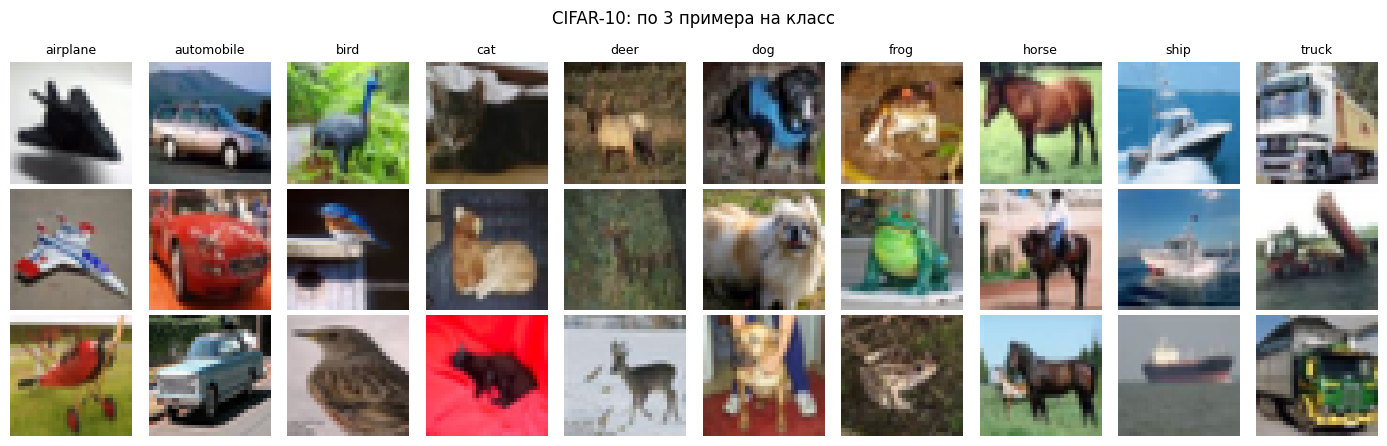

train (50000, 32, 32, 3) 0.0 1.0
test  (10000, 32, 32, 3) 0.0 1.0


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full, y_test = y_train_full.reshape(-1), y_test.reshape(-1)
print(x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape)

# по 3 изображения каждого класса из обучающего набора
fig, axes = plt.subplots(3, 10, figsize=(14, 4.5))
for c in range(10):
    idx = np.flatnonzero(y_train_full == c)[:3]
    for r, i in enumerate(idx):
        axes[r, c].imshow(x_train_full[i])
        axes[r, c].set_title(CLASS_NAMES[c] if r == 0 else '', fontsize=9)
        axes[r, c].axis('off')
plt.suptitle('CIFAR-10: по 3 примера на класс')
plt.tight_layout(); plt.show()

# нормализация в [0, 1]; flatten НЕ нужен - CNN работает с 2D-картинками
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
print('train', x_train_full.shape, x_train_full.min(), x_train_full.max())
print('test ', x_test.shape, x_test.min(), x_test.max())

## П.2 — Архитектура CNN по заданию + формула числа параметров
Структура: `INPUT -> [[CONV -> RELU -> POOL] x 3] -> FLATTEN -> DENSE(relu) -> DROPOUT -> DENSE(softmax)`.

Число параметров сверточного слоя: $P = (M_1 \cdot M_2 \cdot K_{in} + 1) \cdot K_{out}$, где $M_1 \times M_2$ — размер ядра, $K_{in}$ — число входных каналов, $K_{out}$ — число фильтров, `+1` — смещение (bias) на каждый фильтр.

Для полносвязного слоя: $P = (fan_{in} + 1) \cdot fan_{out}$.

In [3]:
def build_cnn(dropout=0.3, n_classes=10):
    """Архитектура из задания: 3 пары Conv+MaxPooling -> Flatten -> Dense(relu) -> Dropout -> Dense(softmax)."""
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
                  optimizer='adam', metrics=['acc'])
    return model

def count_cnn_params(n_classes=10):
    """P_conv = (M1*M2*K_in + 1)*K_out; P_dense = (fan_in + 1)*fan_out."""
    conv1 = (3 * 3 * 3 + 1) * 32       # 896
    conv2 = (3 * 3 * 32 + 1) * 64     # 18496
    conv3 = (3 * 3 * 64 + 1) * 128    # 73856
    dense1 = (4 * 4 * 128 + 1) * 128  # 262272
    dense2 = (128 + 1) * n_classes    # 1290 при 10 классах
    return conv1 + conv2 + conv3 + dense1 + dense2

model10 = build_cnn()
model10.summary()
print('analytic:', count_cnn_params(), '| keras:', model10.count_params())
assert model10.count_params() == count_cnn_params() == 356810

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

analytic: 356810 | keras: 356810


## П.3 — Обучение с валидацией, сохранение лучших весов (callbacks), кривые
`ModelCheckpoint` сохраняет веса только тогда, когда `val_acc` стал лучшим за время обучения. Модель целиком сохраняется отдельно (`.keras`); при загрузке в нее заливаются лучшие веса.

Epoch 1/25


313/313 - 6s - 18ms/step - acc: 0.3731 - loss: 1.7163 - val_acc: 0.5012 - val_loss: 1.3804


Epoch 2/25


313/313 - 5s - 15ms/step - acc: 0.5263 - loss: 1.3159 - val_acc: 0.5984 - val_loss: 1.1343


Epoch 3/25


...

313/313 - 5s - 16ms/step - acc: 0.8862 - loss: 0.3061 - val_acc: 0.7177 - val_loss: 1.0942


Epoch 24/25


313/313 - 5s - 17ms/step - acc: 0.8914 - loss: 0.2942 - val_acc: 0.7260 - val_loss: 1.0612


Epoch 25/25


313/313 - 5s - 16ms/step - acc: 0.8958 - loss: 0.2848 - val_acc: 0.7174 - val_loss: 1.1110


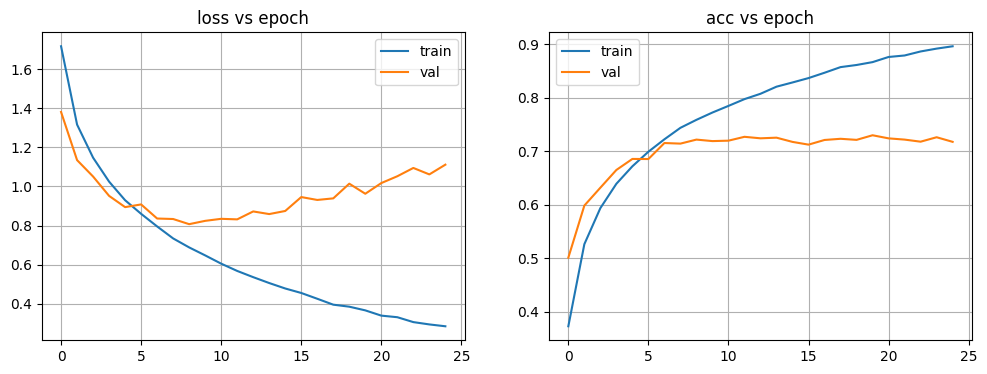

In [4]:
EPOCHS, BATCH = 25, 128
ckpt = keras.callbacks.ModelCheckpoint('best_cnn10.weights.h5', monitor='val_acc',
                                       save_best_only=True, save_weights_only=True, mode='max')
hist = model10.fit(x_train_full, y_train_full, epochs=EPOCHS, batch_size=BATCH,
                   validation_split=0.2, verbose=2, callbacks=[ckpt])
model10.save('cnn10_model.keras')

h = hist.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('loss vs epoch'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(h['acc'], label='train'); ax[1].plot(h['val_acc'], label='val')
ax[1].set_title('acc vs epoch'); ax[1].legend(); ax[1].grid(True)
plt.show()

## П.3 (продолжение) — Тест: загрузка модели с лучшими весами, точность по классам, ошибки
Классифицируем тестовую выборку, выводим по 2 неверно проклассифицированных изображения на каждый класс и процент правильной классификации по классам.

evaluate: loss=1.0042 acc=0.7213


Процент правильной классификации по классам (Ini_10class):
  0 airplane     0.8180
  1 automobile   0.7890
  2 bird         0.6030
  3 cat          0.5000
  4 deer         0.5890
  5 dog          0.6450
  6 frog         0.7920
  7 horse        0.8290
  8 ship         0.8480
  9 truck        0.8000


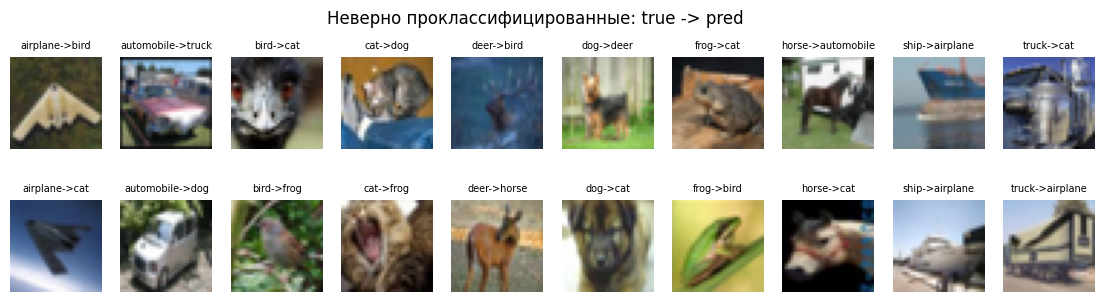

In [5]:
best10 = keras.models.load_model('cnn10_model.keras')
best10.load_weights('best_cnn10.weights.h5')  # заливаем лучшие сохраненные веса
loss, acc = best10.evaluate(x_test, y_test, verbose=0)
print(f'evaluate: loss={loss:.4f} acc={acc:.4f}')

pred10 = np.argmax(best10.predict(x_test, verbose=0), axis=1)
per_class10 = np.array([(pred10[y_test == c] == c).mean() for c in range(10)])
print('Процент правильной классификации по классам (Ini_10class):')
for c, p in enumerate(per_class10):
    print(f'  {c} {CLASS_NAMES[c]:<12} {p:.4f}')

fig, axes = plt.subplots(2, 10, figsize=(14, 3.4))
fig.suptitle('Неверно проклассифицированные: true -> pred')
for c in range(10):
    bad = np.flatnonzero((y_test == c) & (pred10 != c))[:2]
    for r in range(2):
        ax = axes[r, c]; ax.axis('off')
        if r < len(bad):
            i = bad[r]
            ax.imshow(x_test[i])
            ax.set_title(f'{CLASS_NAMES[c]}->{CLASS_NAMES[pred10[i]]}', fontsize=7)
plt.show()

## П.4 — Transfer Learning: обучение на 8 классах
Удаляем из обучающей выборки 2 класса (`cat` и `dog` — произвольные), перенумеровываем метки в 0..7 и обучаем ту же архитектуру с выходным слоем на 8 нейронов. Затем — классификация тестовой выборки по классам.

In [6]:
DROP = [3, 5]  # убираем классы cat(3) и dog(5)
kept = [c for c in range(10) if c not in DROP]
old2new = {c: i for i, c in enumerate(kept)}  # перенумерация меток в 0..7

mask_tr = np.isin(y_train_full, kept)
mask_te = np.isin(y_test, kept)
x8_train = x_train_full[mask_tr]
y8_train = np.array([old2new[c] for c in y_train_full[mask_tr]])
x8_test = x_test[mask_te]
y8_test = np.array([old2new[c] for c in y_test[mask_te]])
print('8-class train/test:', x8_train.shape, x8_test.shape)

model8 = build_cnn(n_classes=8)
model8.fit(x8_train, y8_train, epochs=EPOCHS, batch_size=BATCH,
           validation_split=0.2, verbose=2)

pred8 = np.argmax(model8.predict(x8_test, verbose=0), axis=1)
per_class8 = {c: (pred8[y8_test == old2new[c]] == old2new[c]).mean() for c in kept}
print('Процент правильной классификации (Ini_8class, только 8 классов):')
for c in kept:
    print(f'  {c} {CLASS_NAMES[c]:<12} {per_class8[c]:.4f}')

8-class train/test: (40000, 32, 32, 3) (8000, 32, 32, 3)
Epoch 1/25


250/250 - 5s - 19ms/step - acc: 0.4406 - loss: 1.4690 - val_acc: 0.5636 - val_loss: 1.1717


Epoch 2/25


250/250 - 4s - 16ms/step - acc: 0.5957 - loss: 1.0940 - val_acc: 0.6643 - val_loss: 0.9287


Epoch 3/25


...

Epoch 24/25


250/250 - 4s - 16ms/step - acc: 0.9386 - loss: 0.1669 - val_acc: 0.7980 - val_loss: 0.9238


Epoch 25/25


250/250 - 4s - 15ms/step - acc: 0.9433 - loss: 0.1565 - val_acc: 0.8006 - val_loss: 0.8553


Процент правильной классификации (Ini_8class, только 8 классов):
  0 airplane     0.8030
  1 automobile   0.8670
  2 bird         0.6920
  4 deer         0.6600
  6 frog         0.8100
  7 horse        0.8780
  8 ship         0.8550
  9 truck        0.7920


## П.4 (продолжение) — Дообучение до 10 классов на замороженной базе
`model.pop()` удаляет последний слой: снимаем выходной `Dense(8)`, затем `Dropout` и скрытый `Dense(128)` — то есть оба полносвязных слоя из задания. Замораживаем `base.trainable = False` (весь свёрточный «хвост» до Flatten), ставим новую обучаемую голову `Dense(128, relu) -> Dropout -> Dense(10, softmax)` и обучаем на первоначальных полных данных (10 классов).

In [7]:
model8.pop()  # Dense(8) - выходной полносвязный слой
model8.pop()  # Dropout - стоит между полносвязными, свой добавим в новой голове
model8.pop()  # Dense(128) - скрытый полносвязный слой
base = model8
base.trainable = False  # заморозка обучения всех слоев базовой модели
print('base:', [l.name for l in base.layers])

tl_model = keras.Sequential([
    base,
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax'),
])
tl_model.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
                 optimizer='adam', metrics=['acc'])
tl_model.summary()

hist_tl = tl_model.fit(x_train_full, y_train_full, epochs=EPOCHS, batch_size=BATCH,
                       validation_split=0.2, verbose=2)

pred_tl = np.argmax(tl_model.predict(x_test, verbose=0), axis=1)
per_class_tl = np.array([(pred_tl[y_test == c] == c).mean() for c in range(10)])
print('Процент правильной классификации (TransferLearning_10class):')
for c, p in enumerate(per_class_tl):
    print(f'  {c} {CLASS_NAMES[c]:<12} {p:.4f}')

base: ['conv2d_3', 'max_pooling2d_3', 'conv2d_4', 'max_pooling2d_4', 'conv2d_5', 'max_pooling2d_5', 'flatten_1']


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ (None, 2048)                │          93,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 263,562 (1.01 MB)

...

Epoch 24/25


313/313 - 2s - 8ms/step - acc: 0.9657 - loss: 0.0970 - val_acc: 0.7280 - val_loss: 1.4720


Epoch 25/25


313/313 - 3s - 8ms/step - acc: 0.9677 - loss: 0.0927 - val_acc: 0.7274 - val_loss: 1.4525


Процент правильной классификации (TransferLearning_10class):
  0 airplane     0.8110
  1 automobile   0.8600
  2 bird         0.6410
  3 cat          0.5810
  4 deer         0.6440
  5 dog          0.5520
  6 frog         0.7790
  7 horse        0.7640
  8 ship         0.8370
  9 truck        0.8350


## П.4 (итог) — Сводная таблица точности по классам и выводы

In [8]:
print(f"{'класс':<16}{'Ini_10class':>13}{'Ini_8class':>13}{'TransferLearning_10class':>26}")
print('-' * 68)
for c in range(10):
    p8 = f'{per_class8[c]:.4f}' if c in per_class8 else '   ---'
    print(f'{c} {CLASS_NAMES[c]:<13}{per_class10[c]:>11.4f}{p8:>13}{per_class_tl[c]:>22.4f}')
print('-' * 68)
print(f'среднее по 10 классам:  Ini_10class={per_class10.mean():.4f}  '
      f'TransferLearning_10class={per_class_tl.mean():.4f}')
print(f'среднее по 8 обученным классам:  Ini_8class={np.mean(list(per_class8.values())):.4f}')

класс             Ini_10class   Ini_8class  TransferLearning_10class
--------------------------------------------------------------------
0 airplane          0.8180       0.8030                0.8110
1 automobile        0.7890       0.8670                0.8600
2 bird              0.6030       0.6920                0.6410
3 cat               0.5000          ---                0.5810
4 deer              0.5890       0.6600                0.6440
5 dog               0.6450          ---                0.5520
6 frog              0.7920       0.8100                0.7790
7 horse             0.8290       0.8780                0.7640
8 ship              0.8480       0.8550                0.8370
9 truck             0.8000       0.7920                0.8350
--------------------------------------------------------------------
среднее по 10 классам:  Ini_10class=0.7213  TransferLearning_10class=0.7304
среднее по 8 обученным классам:  Ini_8class=0.7946
